https://youtu.be/zp8clK9yCro


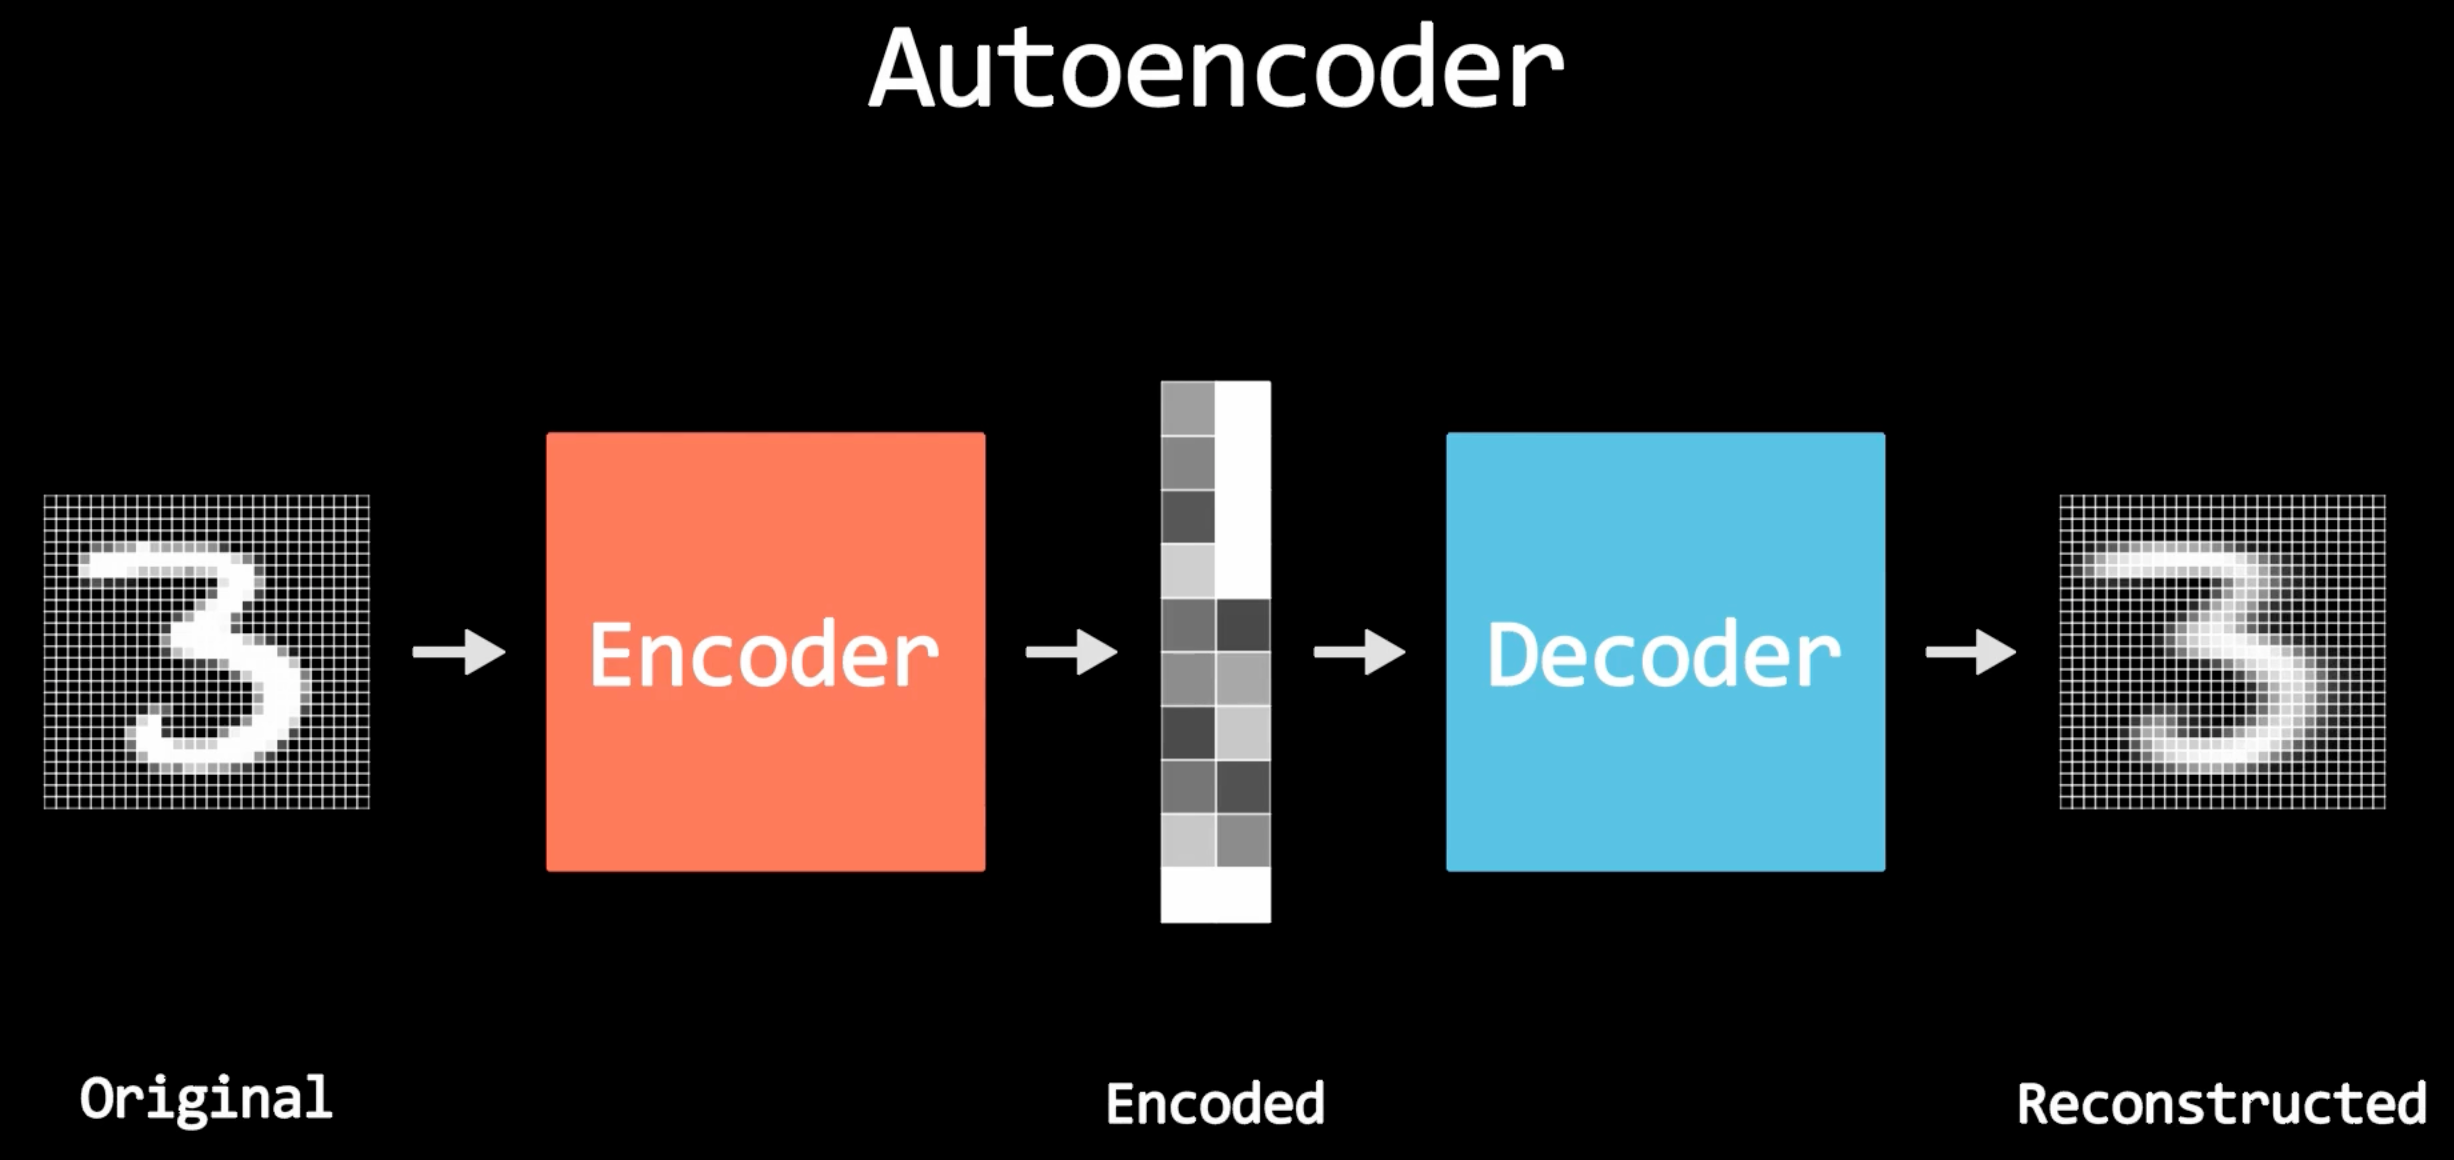


In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [14]:
transform = transforms.ToTensor()  # tensor(0.) tensor(1.)

# transform = transforms.Compose([
#     transforms.ToTensor(),
#     transforms.Normalize((0.5), (0.5))
# ])  # -> tensor(-1.) tensor(1.)

mnist_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

data_loader = torch.utils.data.DataLoader(dataset=mnist_data,
                                          batch_size=64,
                                          shuffle=True)

In [15]:
dataiter = iter(data_loader)
images, labels = next(dataiter)
print(torch.min(images), torch.max(images))

tensor(0.) tensor(1.)


In [ ]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        # Reduce the size
        # N(=batch size), 784(=28x28)
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 128),  # N, 784 -> N, 128
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 12),
            nn.ReLU(),
            nn.Linear(12, 3)  # -> N, 3
        )

        self.decoder = nn.Sequential(
            # N, 3 -> N, 784

            nn.Linear(3, 12),
            nn.ReLU(),
            nn.Linear(12, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 28 * 28),
            nn.Sigmoid()  # Activation Funciton
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

# Note: [-1, 1] -> nn.Tanh

In [19]:
model = Autoencoder()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

In [24]:
num_epochs = 100
outputs = []

for epoch in range(num_epochs):
    for (img, _) in data_loader:
        img = img.reshape(-1, 28 * 28)
        recon = model(img)
        loss = criterion(recon, img)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f'Epoch:{epoch + 1}, Loss:{loss.item():.4f}')
    outputs.append((epoch, img, recon))  # original image, reconstructed image

Epoch:1, Loss:0.0319
Epoch:2, Loss:0.0297
Epoch:3, Loss:0.0369
Epoch:4, Loss:0.0341
Epoch:5, Loss:0.0311
Epoch:6, Loss:0.0336
Epoch:7, Loss:0.0310
Epoch:8, Loss:0.0339
Epoch:9, Loss:0.0316
Epoch:10, Loss:0.0345
Epoch:11, Loss:0.0357
Epoch:12, Loss:0.0335
Epoch:13, Loss:0.0358
Epoch:14, Loss:0.0281
Epoch:15, Loss:0.0330
Epoch:16, Loss:0.0346
Epoch:17, Loss:0.0318
Epoch:18, Loss:0.0345
Epoch:19, Loss:0.0338
Epoch:20, Loss:0.0327
Epoch:21, Loss:0.0288
Epoch:22, Loss:0.0348
Epoch:23, Loss:0.0305
Epoch:24, Loss:0.0341
Epoch:25, Loss:0.0318
Epoch:26, Loss:0.0339
Epoch:27, Loss:0.0324
Epoch:28, Loss:0.0371
Epoch:29, Loss:0.0303
Epoch:30, Loss:0.0322
Epoch:31, Loss:0.0394
Epoch:32, Loss:0.0350
Epoch:33, Loss:0.0342
Epoch:34, Loss:0.0324
Epoch:35, Loss:0.0352
Epoch:36, Loss:0.0267
Epoch:37, Loss:0.0288
Epoch:38, Loss:0.0348
Epoch:39, Loss:0.0274
Epoch:40, Loss:0.0315
Epoch:41, Loss:0.0336
Epoch:42, Loss:0.0371
Epoch:43, Loss:0.0363
Epoch:44, Loss:0.0323
Epoch:45, Loss:0.0302
Epoch:46, Loss:0.02

/var/folders/t2/fjlbn7xs27dcw6dpjyhrlw0h0000gn/T/ipykernel_62441/3916621693.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(9, 2))


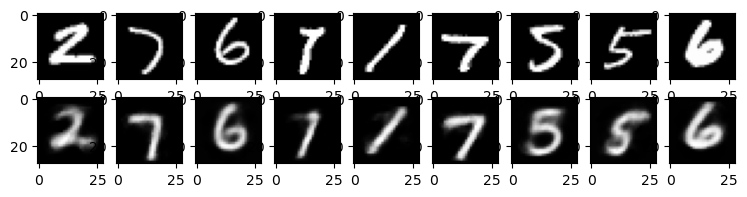

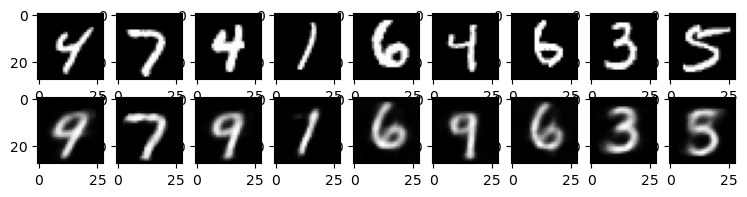

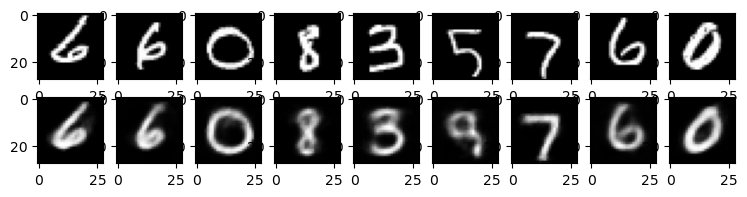

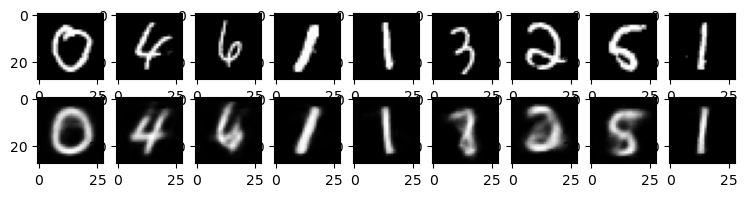

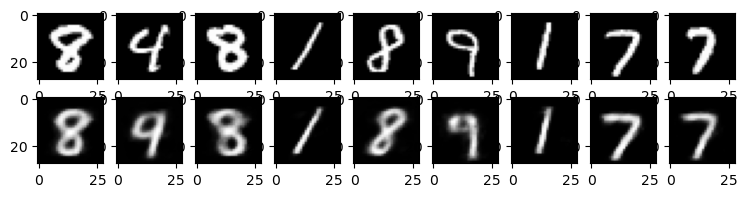

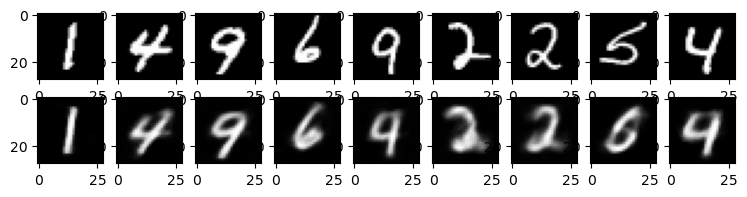

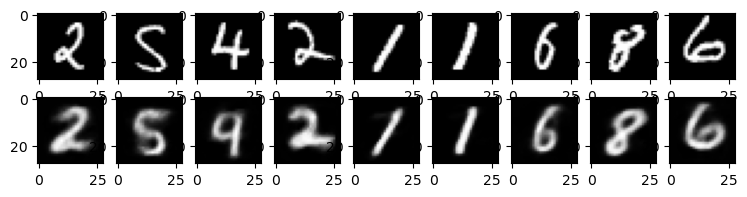

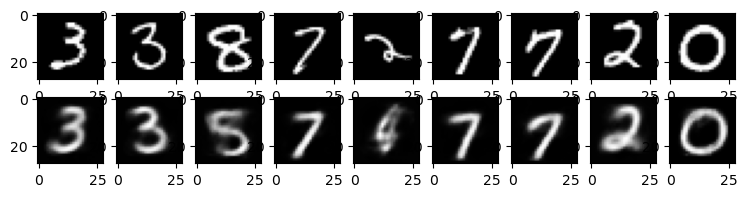

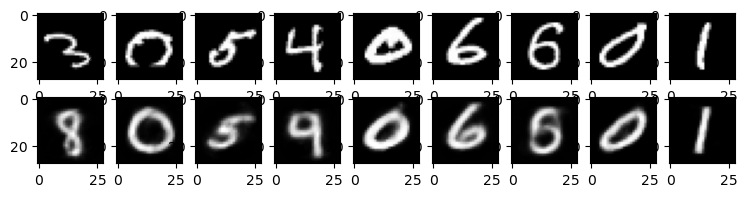

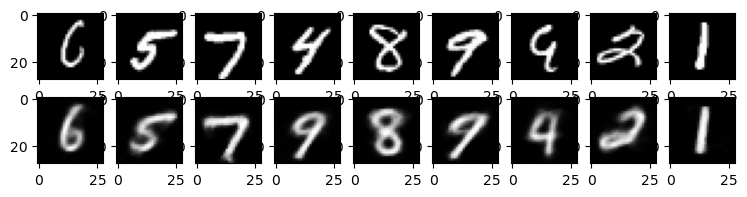

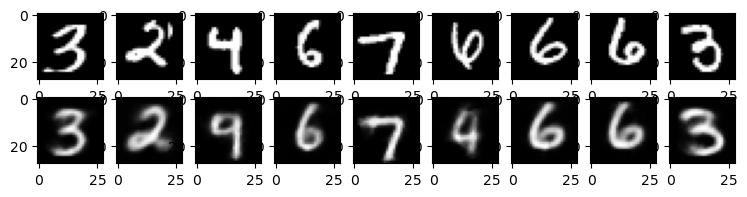

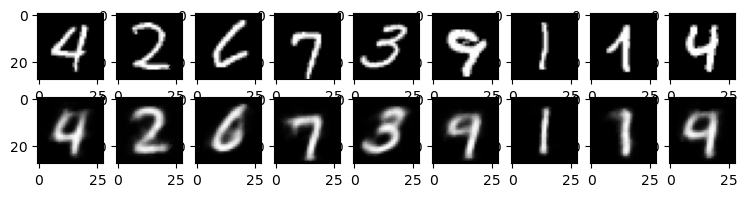

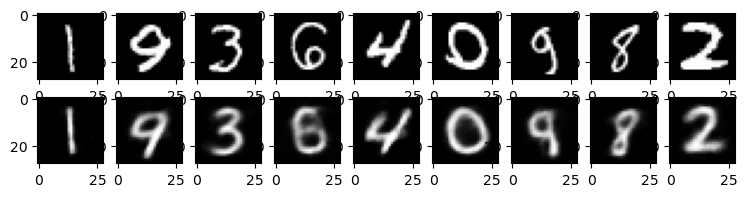

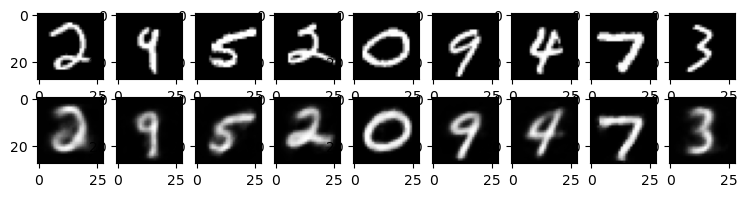

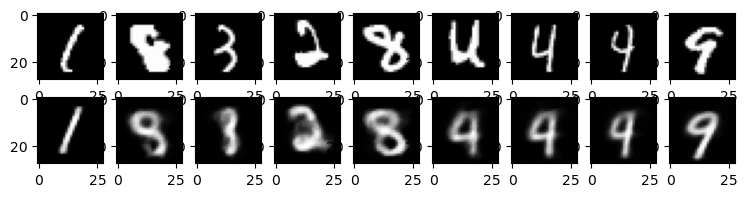

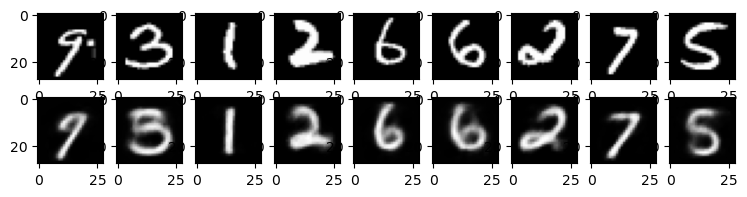

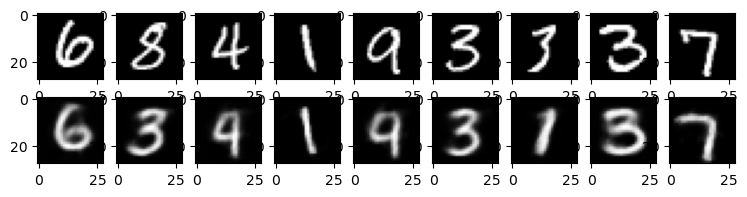

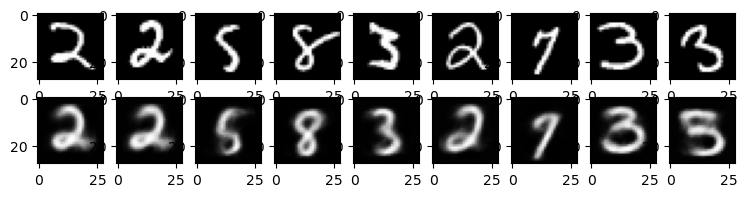

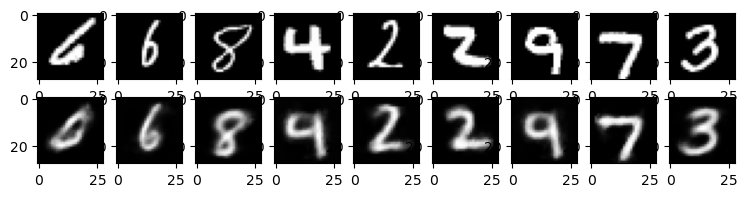

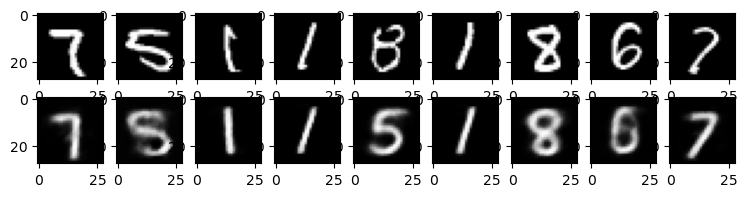

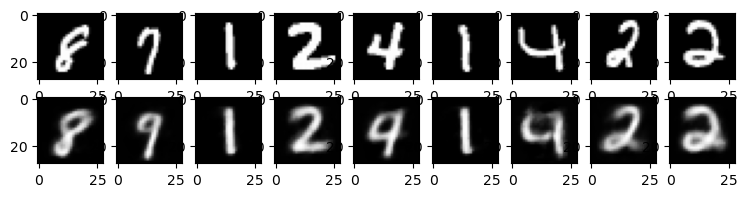

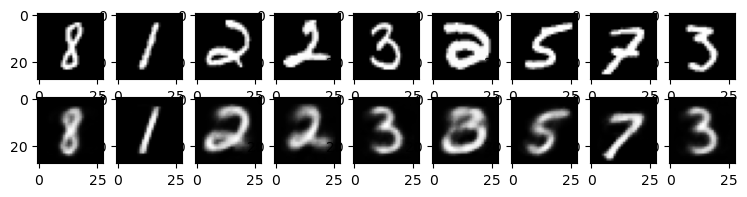

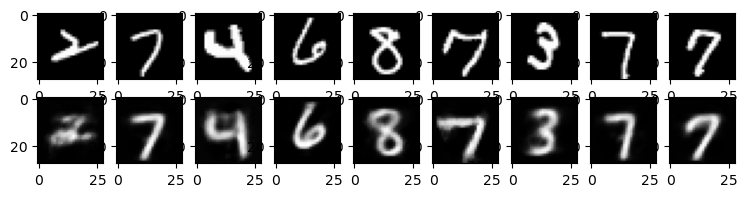

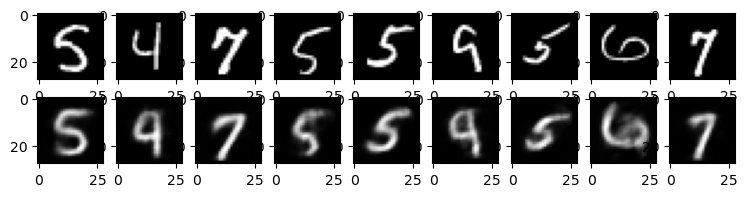

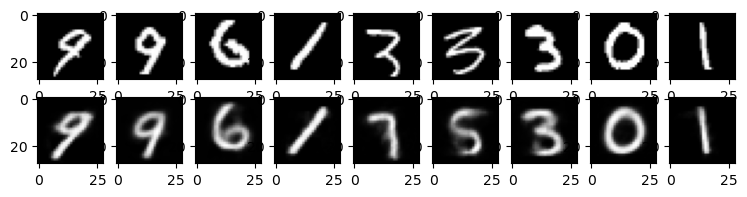

In [25]:
for k in range(0, num_epochs, 4):
    plt.figure(figsize=(9, 2))
    plt.gray()
    imgs = outputs[k][1].detach().numpy()
    recon = outputs[k][2].detach().numpy()
    for i, item in enumerate(imgs):
        if i >= 9:
            break
        plt.subplot(2, 9, i + 1)
        item = item.reshape(-1, 28, 28)
        # item: 1, 28, 28
        plt.imshow(item[0])

    for i, item in enumerate(recon):
        if i >= 9:
            break
        plt.subplot(2, 9, 9 + i + 1)  # row_length + i + 1
        item = item.reshape(-1, 28, 28)
        # item: 1, 28, 28
        plt.imshow(item[0])